In [1]:
# Cell 1: Imports, Setup and Load Saved Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

print("Libraries imported successfully!")

# ─────────────────────────────────────────────────────────────
# LOAD SAVED MODEL FROM PART 4
# ─────────────────────────────────────────────────────────────

pkl_path = '../04_model_improvement/best_f1_model.pkl'

with open(pkl_path, 'rb') as f:
    model_data = pickle.load(f)

best_model      = model_data['model']
best_model_name = model_data['model_name']
feature_columns = model_data['feature_columns']

print(f"\nModel loaded successfully!")
print(f"Model type     : {best_model_name}")
print(f"Trained on     : {model_data['trained_on']}")
print(f"Tested on      : {model_data['tested_on']}")
print(f"Features       : {model_data['num_features']}")
print(f"Saved at       : {model_data['saved_at']}")

# ─────────────────────────────────────────────────────────────
# 2026 FULL DRIVER LINEUP (11 teams, 22 drivers)
# ─────────────────────────────────────────────────────────────

drivers_2026 = [
    # team                  driver                  
    {'team': 'McLaren',       'driver': 'Lando Norris'},
    {'team': 'McLaren',       'driver': 'Oscar Piastri'},
    {'team': 'Mercedes',      'driver': 'George Russell'},
    {'team': 'Mercedes',      'driver': 'Kimi Antonelli'},
    {'team': 'Ferrari',       'driver': 'Charles Leclerc'},
    {'team': 'Ferrari',       'driver': 'Lewis Hamilton'},
    {'team': 'Red Bull',      'driver': 'Max Verstappen'},
    {'team': 'Red Bull',      'driver': 'Isack Hadjar'},
    {'team': 'Williams',      'driver': 'Alex Albon'},
    {'team': 'Williams',      'driver': 'Carlos Sainz'},
    {'team': 'Racing Bulls',  'driver': 'Liam Lawson'},
    {'team': 'Racing Bulls',  'driver': 'Arvid Lindblad'},
    {'team': 'Aston Martin',  'driver': 'Fernando Alonso'},
    {'team': 'Aston Martin',  'driver': 'Lance Stroll'},
    {'team': 'Haas',          'driver': 'Esteban Ocon'},
    {'team': 'Haas',          'driver': 'Oliver Bearman'},
    {'team': 'Audi',          'driver': 'Nico Hulkenberg'},
    {'team': 'Audi',          'driver': 'Gabriel Bortoleto'},
    {'team': 'Alpine',        'driver': 'Pierre Gasly'},
    {'team': 'Alpine',        'driver': 'Franco Colapinto'},
    {'team': 'Cadillac',      'driver': 'Sergio Perez'},
    {'team': 'Cadillac',      'driver': 'Valtteri Bottas'},
]

drivers_df = pd.DataFrame(drivers_2026)
print(f"\n2026 Driver Lineup:")
print(f"Teams   : 11")
print(f"Drivers : {len(drivers_df)}")
print(f"\n{drivers_df.to_string(index=False)}")

# ─────────────────────────────────────────────────────────────
# 2026 RACE CALENDAR (22 races)
# ─────────────────────────────────────────────────────────────

calendar_2026 = [
    {'round': 1,  'race': 'Australia',      'circuit': 'albert_park'},
    {'round': 2,  'race': 'China',          'circuit': 'shanghai'},
    {'round': 3,  'race': 'Japan',          'circuit': 'suzuka'},
    {'round': 4,  'race': 'Miami',          'circuit': 'miami'},
    {'round': 5,  'race': 'Emilia Romagna', 'circuit': 'imola'},
    {'round': 6,  'race': 'Monaco',         'circuit': 'monaco'},
    {'round': 7,  'race': 'Canada',         'circuit': 'villeneuve'},
    {'round': 8,  'race': 'Spain',          'circuit': 'catalunya'},
    {'round': 9,  'race': 'Austria',        'circuit': 'red_bull_ring'},
    {'round': 10, 'race': 'Britain',        'circuit': 'silverstone'},
    {'round': 11, 'race': 'Belgium',        'circuit': 'spa'},
    {'round': 12, 'race': 'Hungary',        'circuit': 'hungaroring'},
    {'round': 13, 'race': 'Netherlands',    'circuit': 'zandvoort'},
    {'round': 14, 'race': 'Italy',          'circuit': 'monza'},
    {'round': 15, 'race': 'Azerbaijan',     'circuit': 'baku'},
    {'round': 16, 'race': 'Singapore',      'circuit': 'marina_bay'},
    {'round': 17, 'race': 'United States',  'circuit': 'americas'},
    {'round': 18, 'race': 'Mexico',         'circuit': 'rodriguez'},
    {'round': 19, 'race': 'Brazil',         'circuit': 'interlagos'},
    {'round': 20, 'race': 'Las Vegas',      'circuit': 'las_vegas'},
    {'round': 21, 'race': 'Qatar',          'circuit': 'losail'},
    {'round': 22, 'race': 'Abu Dhabi',      'circuit': 'yas_marina'},
]

calendar_df = pd.DataFrame(calendar_2026)
print(f"\n2026 Race Calendar:")
print(f"Total Races: {len(calendar_df)}")
print(f"\n{calendar_df.to_string(index=False)}")

print("\n" + "="*60)
print("Cell 1 complete - Model loaded, drivers and calendar ready!")
print("="*60)

Libraries imported successfully!

Model loaded successfully!
Model type     : XGBoost
Trained on     : 2021-2023
Tested on      : 2024
Features       : 21
Saved at       : 2026-04-20 14:13:15

2026 Driver Lineup:
Teams   : 11
Drivers : 22

        team            driver
     McLaren      Lando Norris
     McLaren     Oscar Piastri
    Mercedes    George Russell
    Mercedes    Kimi Antonelli
     Ferrari   Charles Leclerc
     Ferrari    Lewis Hamilton
    Red Bull    Max Verstappen
    Red Bull      Isack Hadjar
    Williams        Alex Albon
    Williams      Carlos Sainz
Racing Bulls       Liam Lawson
Racing Bulls    Arvid Lindblad
Aston Martin   Fernando Alonso
Aston Martin      Lance Stroll
        Haas      Esteban Ocon
        Haas    Oliver Bearman
        Audi   Nico Hulkenberg
        Audi Gabriel Bortoleto
      Alpine      Pierre Gasly
      Alpine  Franco Colapinto
    Cadillac      Sergio Perez
    Cadillac   Valtteri Bottas

2026 Race Calendar:
Total Races: 22

 round   

In [2]:
# Cell 2: Load Historical Data and Build 2026 Driver Features

print("Loading historical F1 data...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. LOAD ALL CSVs
# ─────────────────────────────────────────────────────────────

races                 = pd.read_csv('../data/races.csv')
results               = pd.read_csv('../data/results.csv')
drivers               = pd.read_csv('../data/drivers.csv')
constructors          = pd.read_csv('../data/constructors.csv')
pit_stops             = pd.read_csv('../data/pit_stops.csv')
qualifying            = pd.read_csv('../data/qualifying.csv')
circuits              = pd.read_csv('../data/circuits.csv')
driver_standings      = pd.read_csv('../data/driver_standings.csv')

# Filter to 2020-2024
modern_races    = races[races['year'].between(2020, 2024)].copy()
modern_results  = results[results['raceId'].isin(modern_races['raceId'])].copy()
modern_pitstops = pit_stops[pit_stops['raceId'].isin(modern_races['raceId'])].copy()

print(f"Races loaded       : {modern_races.shape[0]}")
print(f"Results loaded     : {modern_results.shape[0]}")
print(f"Pit stops loaded   : {modern_pitstops.shape[0]}")

# ─────────────────────────────────────────────────────────────
# 2. BUILD DRIVER NAME LOOKUP
# ─────────────────────────────────────────────────────────────

drivers['full_name'] = drivers['forename'] + ' ' + drivers['surname']
driver_lookup = drivers[['driverId', 'full_name']].copy()

# Merge results with driver names
merged = modern_results.merge(
    modern_races[['raceId', 'year', 'round', 'circuitId']], on='raceId'
).merge(driver_lookup, on='driverId')

merged['is_winner'] = (merged['positionOrder'] == 1).astype(int)
merged['is_dnf']    = (merged['positionOrder'] > 20).astype(int)

print(f"\nMerged dataset shape: {merged.shape}")

# ─────────────────────────────────────────────────────────────
# 3. BUILD DRIVER HISTORICAL FEATURES
# ─────────────────────────────────────────────────────────────

print("\nBuilding driver historical features...")

driver_hist = merged.groupby('full_name').agg(
    driver_avg_points    = ('points',       'mean'),
    driver_win_rate      = ('is_winner',    'mean'),
    driver_avg_finish    = ('positionOrder','mean'),
    recent_win_rate      = ('is_winner',    'mean'),
    driver_form_3        = ('points',       'mean'),
    driver_form_5        = ('points',       'mean'),
    dnf_rate             = ('is_dnf',       'mean'),
    total_races          = ('raceId',       'count')
).reset_index()

# ─────────────────────────────────────────────────────────────
# 4. BUILD CIRCUIT WIN RATES PER DRIVER
# ─────────────────────────────────────────────────────────────

circuit_wins = merged.groupby(['full_name', 'circuitId']).agg(
    win_rate_at_circuit    = ('is_winner', 'mean'),
    avg_points_at_circuit  = ('points',    'mean')
).reset_index()

# ─────────────────────────────────────────────────────────────
# 5. BUILD CONSTRUCTOR FEATURES
# ─────────────────────────────────────────────────────────────

const_lookup = constructors[['constructorId', 'name']].copy()
const_merged = modern_results.merge(
    modern_races[['raceId', 'year']], on='raceId'
).merge(const_lookup, on='constructorId')

const_hist = const_merged.groupby('name').agg(
    constructor_avg_points = ('points', 'mean'),
    constructor_form_3     = ('points', 'mean'),
).reset_index()
const_hist.columns = ['team_hist', 'constructor_avg_points', 'constructor_form_3']

# ─────────────────────────────────────────────────────────────
# 6. MAP 2026 DRIVERS TO HISTORICAL NAMES
# ─────────────────────────────────────────────────────────────

# Some 2026 drivers may have different name formats in dataset
name_map = {
    'Lando Norris'      : 'Lando Norris',
    'Oscar Piastri'     : 'Oscar Piastri',
    'George Russell'    : 'George Russell',
    'Kimi Antonelli'    : 'Andrea Kimi Antonelli',
    'Charles Leclerc'   : 'Charles Leclerc',
    'Lewis Hamilton'    : 'Lewis Hamilton',
    'Max Verstappen'    : 'Max Verstappen',
    'Isack Hadjar'      : 'Isack Hadjar',
    'Alex Albon'        : 'Alexander Albon',
    'Carlos Sainz'      : 'Carlos Sainz',
    'Liam Lawson'       : 'Liam Lawson',
    'Arvid Lindblad'    : 'Arvid Lindblad',
    'Fernando Alonso'   : 'Fernando Alonso',
    'Lance Stroll'      : 'Lance Stroll',
    'Esteban Ocon'      : 'Esteban Ocon',
    'Oliver Bearman'    : 'Oliver Bearman',
    'Nico Hulkenberg'   : 'Nico Hulkenberg',
    'Gabriel Bortoleto' : 'Gabriel Bortoleto',
    'Pierre Gasly'      : 'Pierre Gasly',
    'Franco Colapinto'  : 'Franco Colapinto',
    'Sergio Perez'      : 'Sergio Pérez',
    'Valtteri Bottas'   : 'Valtteri Bottas',
}

# Map 2026 team names to historical constructor names
team_map = {
    'McLaren'      : 'McLaren',
    'Mercedes'     : 'Mercedes',
    'Ferrari'      : 'Ferrari',
    'Red Bull'     : 'Red Bull',
    'Williams'     : 'Williams',
    'Racing Bulls' : 'AlphaTauri',
    'Aston Martin' : 'Aston Martin',
    'Haas'         : 'Haas F1 Team',
    'Audi'         : 'Alfa Romeo',
    'Alpine'       : 'Alpine F1 Team',
    'Cadillac'     : 'Haas F1 Team',
}

# ─────────────────────────────────────────────────────────────
# 7. BUILD MASTER 2026 DRIVER FEATURE TABLE
# ─────────────────────────────────────────────────────────────

# Default features for rookies with no history
rookie_defaults = {
    'driver_avg_points'   : 1.0,
    'driver_win_rate'     : 0.0,
    'driver_avg_finish'   : 15.0,
    'recent_win_rate'     : 0.0,
    'driver_form_3'       : 1.0,
    'driver_form_5'       : 1.0,
    'dnf_rate'            : 0.05,
}

driver_features_2026 = []

for _, row in drivers_df.iterrows():
    driver   = row['driver']
    team     = row['team']
    hist_name = name_map.get(driver, driver)
    hist_team = team_map.get(team, team)

    # Get driver historical stats
    hist = driver_hist[driver_hist['full_name'] == hist_name]

    if len(hist) > 0:
        feats = hist.iloc[0].to_dict()
    else:
        # Rookie - use defaults
        feats = {'full_name': hist_name, **rookie_defaults}

    # Get constructor stats
    const = const_hist[const_hist['team_hist'] == hist_team]
    if len(const) > 0:
        feats['constructor_avg_points'] = const.iloc[0]['constructor_avg_points']
        feats['constructor_form_3']     = const.iloc[0]['constructor_form_3']
    else:
        feats['constructor_avg_points'] = 5.0
        feats['constructor_form_3']     = 5.0

    feats['driver'] = driver
    feats['team']   = team
    driver_features_2026.append(feats)

driver_features_df = pd.DataFrame(driver_features_2026)

print(f"\n2026 Driver Feature Table:")
print(f"Drivers with history : {driver_hist['full_name'].isin(list(name_map.values())).sum()}")
print(f"Rookie drivers       : {sum(1 for d in name_map.values() if d not in driver_hist['full_name'].values)}")

display_cols = ['driver', 'team', 'driver_avg_points',
                'driver_win_rate', 'driver_avg_finish', 'dnf_rate']
print(f"\n{driver_features_df[display_cols].to_string(index=False)}")

# Store circuit wins for later use
circuit_wins_lookup = circuit_wins.copy()

print("\n" + "="*60)
print("Cell 2 complete - Historical features built for all 22 drivers!")
print("="*60)

Loading historical F1 data...
Races loaded       : 107
Results loaded     : 2139
Pit stops loaded   : 3934

Merged dataset shape: (2139, 24)

Building driver historical features...

2026 Driver Feature Table:
Drivers with history : 17
Rookie drivers       : 5

           driver         team  driver_avg_points  driver_win_rate  driver_avg_finish  dnf_rate
     Lando Norris      McLaren           8.420561         0.037383           7.168224      0.00
    Oscar Piastri      McLaren           7.543478         0.043478           7.891304      0.00
   George Russell     Mercedes           6.205607         0.028037           9.495327      0.00
   Kimi Antonelli     Mercedes           1.000000         0.000000          15.000000      0.05
  Charles Leclerc      Ferrari           9.906542         0.056075           7.000000      0.00
   Lewis Hamilton      Ferrari          13.108491         0.198113           5.103774      0.00
   Max Verstappen     Red Bull          18.359813         0.514019 

In [3]:
# Cell 3: Build 2026 Race Entries and Predict Each Race

print("Building 2026 race entries and predicting winners...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. GRID POSITION ASSIGNMENTS PER TEAM STRENGTH
# ─────────────────────────────────────────────────────────────

# Based on 2024/2025 form and 2026 regulation reset factor
team_strength = {
    'McLaren'      : 1,
    'Ferrari'      : 2,
    'Mercedes'     : 3,
    'Red Bull'     : 4,
    'Williams'     : 5,
    'Aston Martin' : 6,
    'Racing Bulls' : 7,
    'Alpine'       : 8,
    'Haas'         : 9,
    'Audi'         : 10,
    'Cadillac'     : 11,
}

# Within each team - driver 1 slightly ahead of driver 2
team_driver_order = {
    'McLaren'      : ['Lando Norris',    'Oscar Piastri'],
    'Mercedes'     : ['George Russell',  'Kimi Antonelli'],
    'Ferrari'      : ['Charles Leclerc', 'Lewis Hamilton'],
    'Red Bull'     : ['Max Verstappen',  'Isack Hadjar'],
    'Williams'     : ['Carlos Sainz',    'Alex Albon'],
    'Racing Bulls' : ['Liam Lawson',     'Arvid Lindblad'],
    'Aston Martin' : ['Fernando Alonso', 'Lance Stroll'],
    'Alpine'       : ['Pierre Gasly',    'Franco Colapinto'],
    'Haas'         : ['Esteban Ocon',    'Oliver Bearman'],
    'Audi'         : ['Nico Hulkenberg', 'Gabriel Bortoleto'],
    'Cadillac'     : ['Sergio Perez',    'Valtteri Bottas'],
}

# Build base grid positions
grid_assignments = {}
grid_pos = 1
for team, strength in sorted(team_strength.items(), key=lambda x: x[1]):
    drivers_in_team = team_driver_order[team]
    for i, driver in enumerate(drivers_in_team):
        grid_assignments[driver] = grid_pos + i

print("Base grid assignments (by team strength):")
for driver, pos in grid_assignments.items():
    print(f"  P{pos:2} - {driver}")

# ─────────────────────────────────────────────────────────────
# 2. CIRCUIT ID LOOKUP FROM HISTORICAL DATA
# ─────────────────────────────────────────────────────────────

circuit_name_map = {
    'albert_park'  : circuits[circuits['name'].str.contains('Albert', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Albert', case=False)]) > 0 else 1,
    'shanghai'     : circuits[circuits['name'].str.contains('Shanghai', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Shanghai', case=False)]) > 0 else 2,
    'suzuka'       : circuits[circuits['name'].str.contains('Suzuka', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Suzuka', case=False)]) > 0 else 3,
    'miami'        : circuits[circuits['name'].str.contains('Miami', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Miami', case=False)]) > 0 else 4,
    'imola'        : circuits[circuits['name'].str.contains('Imola', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Imola', case=False)]) > 0 else 5,
    'monaco'       : circuits[circuits['name'].str.contains('Monaco', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Monaco', case=False)]) > 0 else 6,
    'villeneuve'   : circuits[circuits['name'].str.contains('Gilles', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Gilles', case=False)]) > 0 else 7,
    'catalunya'    : circuits[circuits['name'].str.contains('Catalunya', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Catalunya', case=False)]) > 0 else 8,
    'red_bull_ring': circuits[circuits['name'].str.contains('Red Bull Ring', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Red Bull Ring', case=False)]) > 0 else 9,
    'silverstone'  : circuits[circuits['name'].str.contains('Silverstone', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Silverstone', case=False)]) > 0 else 10,
    'spa'          : circuits[circuits['name'].str.contains('Spa', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Spa', case=False)]) > 0 else 11,
    'hungaroring'  : circuits[circuits['name'].str.contains('Hungaroring', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Hungaroring', case=False)]) > 0 else 12,
    'zandvoort'    : circuits[circuits['name'].str.contains('Zandvoort', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Zandvoort', case=False)]) > 0 else 13,
    'monza'        : circuits[circuits['name'].str.contains('Monza', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Monza', case=False)]) > 0 else 14,
    'baku'         : circuits[circuits['name'].str.contains('Baku', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Baku', case=False)]) > 0 else 15,
    'marina_bay'   : circuits[circuits['name'].str.contains('Marina', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Marina', case=False)]) > 0 else 16,
    'americas'     : circuits[circuits['name'].str.contains('Americas', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Americas', case=False)]) > 0 else 17,
    'rodriguez'    : circuits[circuits['name'].str.contains('Rodriguez', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Rodriguez', case=False)]) > 0 else 18,
    'interlagos'   : circuits[circuits['name'].str.contains('Interlagos', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Interlagos', case=False)]) > 0 else 19,
    'las_vegas'    : circuits[circuits['name'].str.contains('Vegas', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Vegas', case=False)]) > 0 else 20,
    'losail'       : circuits[circuits['name'].str.contains('Losail', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Losail', case=False)]) > 0 else 21,
    'yas_marina'   : circuits[circuits['name'].str.contains('Yas', case=False)]['circuitId'].values[0] if len(circuits[circuits['name'].str.contains('Yas', case=False)]) > 0 else 22,
}

print(f"\nCircuit IDs mapped: {len(circuit_name_map)}")

# ─────────────────────────────────────────────────────────────
# 3. BUILD FULL RACE ENTRY LIST FOR ALL 22 RACES
# ─────────────────────────────────────────────────────────────

all_race_entries = []

for _, race in calendar_df.iterrows():
    rnd        = race['round']
    race_name  = race['race']
    circuit_key = race['circuit']
    circuit_id  = circuit_name_map.get(circuit_key, rnd)

    # Add small grid randomness per race (qualifying variation)
    np.random.seed(rnd * 42)
    grid_noise = np.random.randint(-2, 3, size=22)

    for i, (_, drv) in enumerate(drivers_df.iterrows()):
        driver = drv['driver']
        team   = drv['team']

        # Base grid + noise, clipped to 1-22
        base_grid = grid_assignments[driver]
        race_grid = int(np.clip(base_grid + grid_noise[i], 1, 22))

        # Get driver features
        drv_feat = driver_features_df[
            driver_features_df['driver'] == driver
        ].iloc[0]

        # Get circuit specific win rate
        hist_name  = name_map.get(driver, driver)
        circ_stats = circuit_wins_lookup[
            (circuit_wins_lookup['full_name'] == hist_name) &
            (circuit_wins_lookup['circuitId'] == circuit_id)
        ]

        win_rate_circ   = circ_stats['win_rate_at_circuit'].values[0]   if len(circ_stats) > 0 else 0.0
        avg_pts_circ    = circ_stats['avg_points_at_circuit'].values[0] if len(circ_stats) > 0 else drv_feat['driver_avg_points']

        entry = {
            'round'                  : rnd,
            'race'                   : race_name,
            'driver'                 : driver,
            'team'                   : team,
            'grid'                   : race_grid,
            'grid_squared'           : race_grid ** 2,
            'is_pole'                : int(race_grid == 1),
            'is_front_row'           : int(race_grid <= 2),
            'driver_avg_points'      : drv_feat['driver_avg_points'],
            'driver_form_3'          : drv_feat['driver_form_3'],
            'driver_form_5'          : drv_feat['driver_form_5'],
            'recent_win_rate'        : drv_feat['recent_win_rate'],
            'win_rate_at_circuit'    : win_rate_circ,
            'avg_points_at_circuit'  : avg_pts_circ,
            'constructor_avg_points' : drv_feat['constructor_avg_points'],
            'constructor_form_3'     : drv_feat['constructor_form_3'],
            'championship_position'  : i + 1,
            'championship_points'    : 0,
            'dnf_rate'               : drv_feat['dnf_rate'],
            'round'                  : rnd,
            'driver_avg_finish'      : drv_feat['driver_avg_finish'],
            'driver_win_rate'        : drv_feat['driver_win_rate'],
            'typical_gain'           : drv_feat['driver_avg_finish'] - race_grid,
            'num_pitstops'           : 2,
            'avg_pitstop_time'       : 25000,
        }
        all_race_entries.append(entry)

entries_df = pd.DataFrame(all_race_entries)

print(f"\nTotal race entries built: {entries_df.shape[0]}")
print(f"Races                  : {entries_df['race'].nunique()}")
print(f"Drivers per race       : {entries_df.groupby('race')['driver'].count().mean():.0f}")

# ─────────────────────────────────────────────────────────────
# 4. PREDICT WIN PROBABILITY FOR EVERY ENTRY
# ─────────────────────────────────────────────────────────────

print("\nRunning predictions...")

X_2026      = entries_df[feature_columns]
win_probas  = best_model.predict_proba(X_2026)[:, 1]
entries_df['win_probability'] = win_probas

# ─────────────────────────────────────────────────────────────
# 5. PICK PREDICTED WINNER PER RACE
# ─────────────────────────────────────────────────────────────

race_results = []

for race_name in calendar_df['race']:
    race_df = entries_df[entries_df['race'] == race_name].copy()
    race_df = race_df.sort_values('win_probability', ascending=False)

    winner     = race_df.iloc[0]
    runner_up  = race_df.iloc[1]
    third      = race_df.iloc[2]

    race_results.append({
        'race'          : race_name,
        'round'         : race_df['round'].iloc[0],
        'winner'        : winner['driver'],
        'winner_team'   : winner['team'],
        'winner_prob'   : winner['win_probability'],
        'p2'            : runner_up['driver'],
        'p2_team'       : runner_up['team'],
        'p3'            : third['driver'],
        'p3_team'       : third['team'],
    })

race_results_df = pd.DataFrame(race_results)

print(f"\n2026 PREDICTED RACE WINNERS:")
print(f"{'Rnd':<5} {'Race':<18} {'Winner':<22} {'Team':<15} {'Prob':<8}")
print("-" * 70)
for _, r in race_results_df.iterrows():
    print(f"R{int(r['round']):<4} {r['race']:<18} {r['winner']:<22} "
          f"{r['winner_team']:<15} {r['winner_prob']:.3f}")

print("\n" + "="*60)
print("Cell 3 complete - All 22 race winners predicted!")
print("="*60)

Building 2026 race entries and predicting winners...
Base grid assignments (by team strength):
  P 1 - Lando Norris
  P 2 - Oscar Piastri
  P 1 - Charles Leclerc
  P 2 - Lewis Hamilton
  P 1 - George Russell
  P 2 - Kimi Antonelli
  P 1 - Max Verstappen
  P 2 - Isack Hadjar
  P 1 - Carlos Sainz
  P 2 - Alex Albon
  P 1 - Fernando Alonso
  P 2 - Lance Stroll
  P 1 - Liam Lawson
  P 2 - Arvid Lindblad
  P 1 - Pierre Gasly
  P 2 - Franco Colapinto
  P 1 - Esteban Ocon
  P 2 - Oliver Bearman
  P 1 - Nico Hulkenberg
  P 2 - Gabriel Bortoleto
  P 1 - Sergio Perez
  P 2 - Valtteri Bottas

Circuit IDs mapped: 22

Total race entries built: 484
Races                  : 22
Drivers per race       : 22

Running predictions...

2026 PREDICTED RACE WINNERS:
Rnd   Race               Winner                 Team            Prob    
----------------------------------------------------------------------
R1    Australia          Max Verstappen         Red Bull        0.576
R2    China              Max Vers

In [4]:
# Cell 4: Simulate Full 2026 Championship Points Table

print("Simulating 2026 Championship Points...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. F1 POINTS SYSTEM
# ─────────────────────────────────────────────────────────────

points_system = {
    1: 25, 2: 18, 3: 15, 4: 12, 5: 10,
    6: 8,  7: 6,  8: 4,  9: 2,  10: 1
}

# ─────────────────────────────────────────────────────────────
# 2. SIMULATE FULL RACE RESULTS (TOP 10 PER RACE)
# ─────────────────────────────────────────────────────────────

championship_points = {driver: 0 for driver in drivers_df['driver']}
constructor_points  = {team: 0   for team   in drivers_df['team'].unique()}

detailed_results = []

for race_name in calendar_df['race']:
    race_df = entries_df[entries_df['race'] == race_name].copy()
    race_df = race_df.sort_values('win_probability', ascending=False).reset_index(drop=True)

    for pos in range(1, 23):
        if pos - 1 < len(race_df):
            driver = race_df.iloc[pos - 1]['driver']
            team   = race_df.iloc[pos - 1]['team']
            pts    = points_system.get(pos, 0)

            championship_points[driver] += pts
            constructor_points[team]    += pts

            detailed_results.append({
                'race'     : race_name,
                'position' : pos,
                'driver'   : driver,
                'team'     : team,
                'points'   : pts,
            })

detailed_df = pd.DataFrame(detailed_results)

# ─────────────────────────────────────────────────────────────
# 3. DRIVER CHAMPIONSHIP STANDINGS
# ─────────────────────────────────────────────────────────────

driver_standings_2026 = pd.DataFrame([
    {'driver': d, 'team': drivers_df[drivers_df['driver'] == d]['team'].values[0],
     'points': p}
    for d, p in championship_points.items()
]).sort_values('points', ascending=False).reset_index(drop=True)

driver_standings_2026['position'] = driver_standings_2026.index + 1

# Count wins per driver
wins_count = race_results_df['winner'].value_counts().reset_index()
wins_count.columns = ['driver', 'wins']
driver_standings_2026 = driver_standings_2026.merge(wins_count, on='driver', how='left')
driver_standings_2026['wins'] = driver_standings_2026['wins'].fillna(0).astype(int)

# Count podiums
podiums_count = {}
for _, row in detailed_df[detailed_df['position'] <= 3].iterrows():
    podiums_count[row['driver']] = podiums_count.get(row['driver'], 0) + 1

driver_standings_2026['podiums'] = driver_standings_2026['driver'].map(
    podiums_count).fillna(0).astype(int)

# ─────────────────────────────────────────────────────────────
# 4. CONSTRUCTOR CHAMPIONSHIP STANDINGS
# ─────────────────────────────────────────────────────────────

constructor_standings_2026 = pd.DataFrame([
    {'team': t, 'points': p}
    for t, p in constructor_points.items()
]).sort_values('points', ascending=False).reset_index(drop=True)

constructor_standings_2026['position'] = constructor_standings_2026.index + 1

# Constructor wins
team_wins = race_results_df['winner_team'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']
constructor_standings_2026 = constructor_standings_2026.merge(
    team_wins, on='team', how='left')
constructor_standings_2026['wins'] = constructor_standings_2026['wins'].fillna(0).astype(int)

# ─────────────────────────────────────────────────────────────
# 5. PRINT DRIVER STANDINGS
# ─────────────────────────────────────────────────────────────

print("\n2026 PREDICTED DRIVER CHAMPIONSHIP STANDINGS")
print("="*65)
print(f"{'Pos':<5} {'Driver':<22} {'Team':<15} {'Pts':<8} {'Wins':<6} {'Podiums'}")
print("-"*65)

medal = {1: 'CHAMPION', 2: 'P2', 3: 'P3'}

for _, row in driver_standings_2026.iterrows():
    pos    = int(row['position'])
    tag    = medal.get(pos, '')
    marker = '>>>' if pos == 1 else '   '
    print(f"{marker} {pos:<4} {row['driver']:<22} {row['team']:<15} "
          f"{int(row['points']):<8} {int(row['wins']):<6} "
          f"{int(row['podiums']):<7} {tag}")

# ─────────────────────────────────────────────────────────────
# 6. PRINT CONSTRUCTOR STANDINGS
# ─────────────────────────────────────────────────────────────

print("\n\n2026 PREDICTED CONSTRUCTOR CHAMPIONSHIP STANDINGS")
print("="*55)
print(f"{'Pos':<5} {'Team':<18} {'Points':<10} {'Wins'}")
print("-"*55)

for _, row in constructor_standings_2026.iterrows():
    pos    = int(row['position'])
    marker = '>>>' if pos == 1 else '   '
    print(f"{marker} {pos:<4} {row['team']:<18} "
          f"{int(row['points']):<10} {int(row['wins'])}")

# ─────────────────────────────────────────────────────────────
# 7. CHAMPIONSHIP VERDICT
# ─────────────────────────────────────────────────────────────

champion_driver      = driver_standings_2026.iloc[0]
champion_constructor = constructor_standings_2026.iloc[0]

print("\n" + "="*60)
print("2026 CHAMPIONSHIP PREDICTION VERDICT")
print("="*60)
print(f"DRIVERS CHAMPION    : {champion_driver['driver']}")
print(f"Team                : {champion_driver['team']}")
print(f"Points              : {int(champion_driver['points'])}")
print(f"Wins                : {int(champion_driver['wins'])}")
print(f"Podiums             : {int(champion_driver['podiums'])}")
print(f"\nCONSTRUCTORS CHAMP  : {champion_constructor['team']}")
print(f"Points              : {int(champion_constructor['points'])}")
print(f"Wins                : {int(champion_constructor['wins'])}")
print("="*60)

# Save results for next cells
race_results_df.to_csv('predicted_race_winners_2026.csv', index=False)
driver_standings_2026.to_csv('predicted_driver_standings_2026.csv', index=False)
constructor_standings_2026.to_csv('predicted_constructor_standings_2026.csv', index=False)

print("\nCSV files saved:")
print("  predicted_race_winners_2026.csv")
print("  predicted_driver_standings_2026.csv")
print("  predicted_constructor_standings_2026.csv")

print("\nCell 4 complete - Full championship simulated!")

Simulating 2026 Championship Points...

2026 PREDICTED DRIVER CHAMPIONSHIP STANDINGS
Pos   Driver                 Team            Pts      Wins   Podiums
-----------------------------------------------------------------
>>> 1    Max Verstappen         Red Bull        431      14     19      CHAMPION
    2    Oscar Piastri          McLaren         174      2      8       P2
    3    Kimi Antonelli         Mercedes        143      0      3       P3
    4    Lewis Hamilton         Ferrari         136      1      6       
    5    George Russell         Mercedes        135      1      2       
    6    Isack Hadjar           Red Bull        98       0      4       
    7    Liam Lawson            Racing Bulls    98       0      1       
    8    Alex Albon             Williams        93       0      3       
    9    Pierre Gasly           Alpine          93       1      1       
    10   Lando Norris           McLaren         84       1      4       
    11   Lance Stroll           Aston 

Generating 2026 Championship Visualizations...


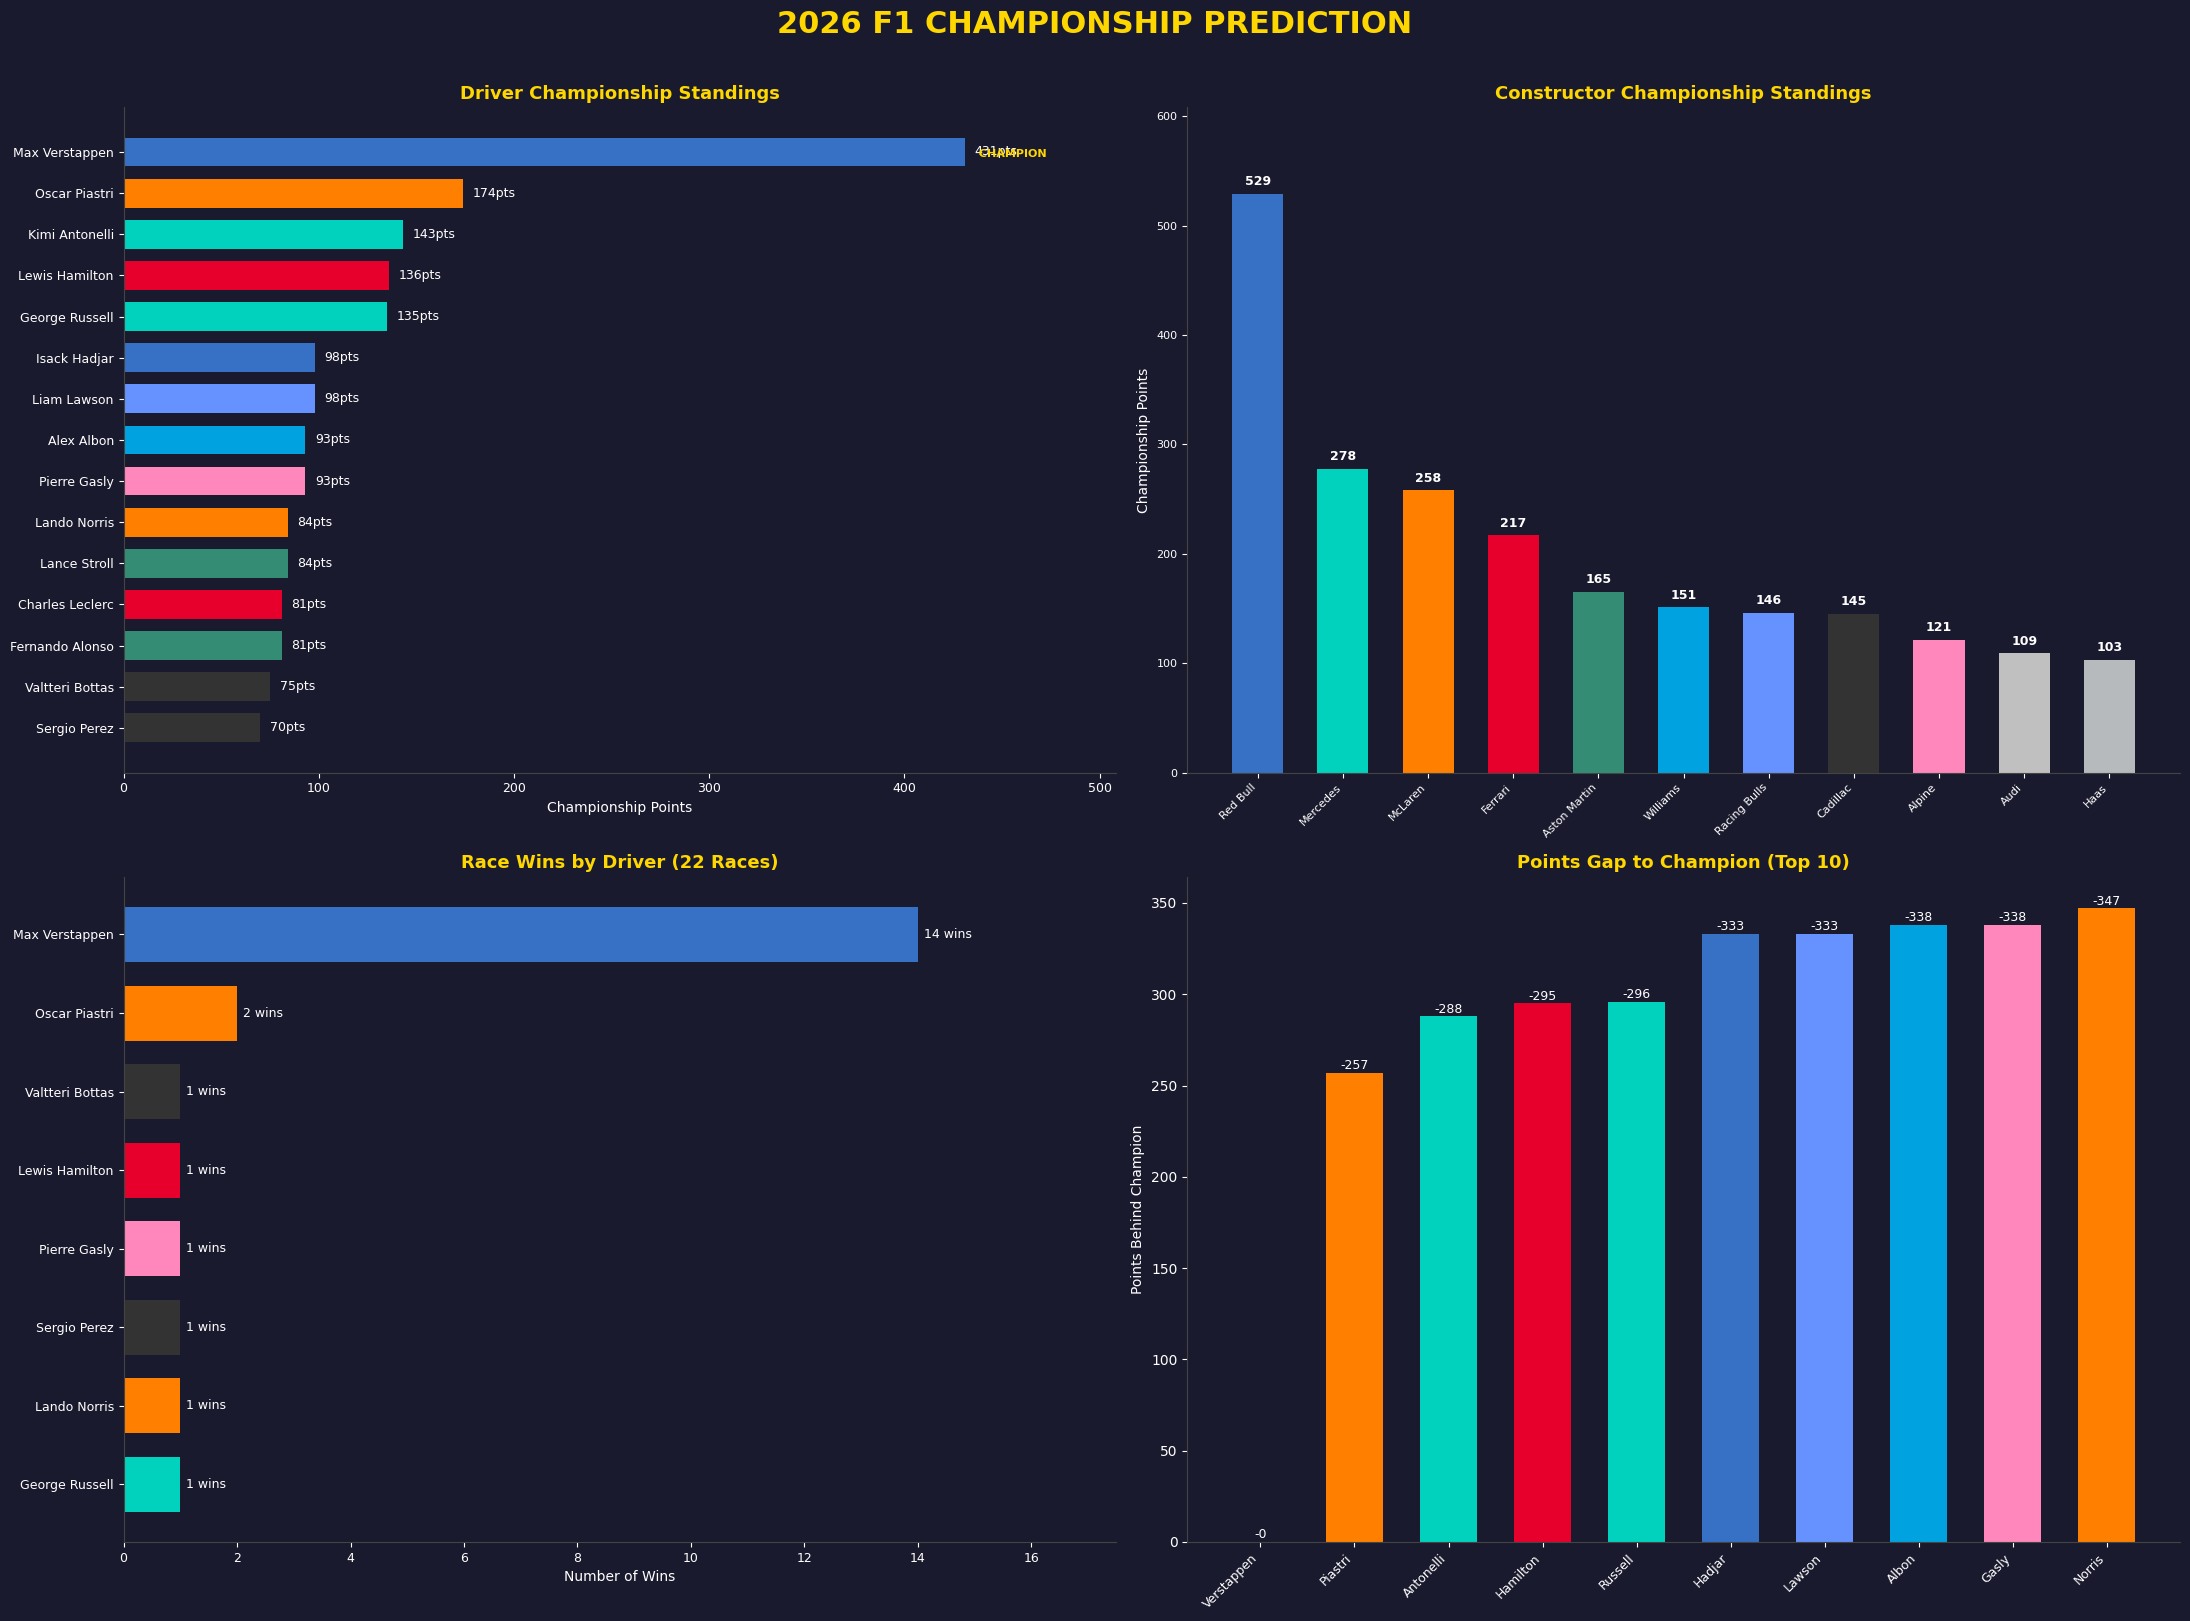

Saved: championship_standings_2026.png


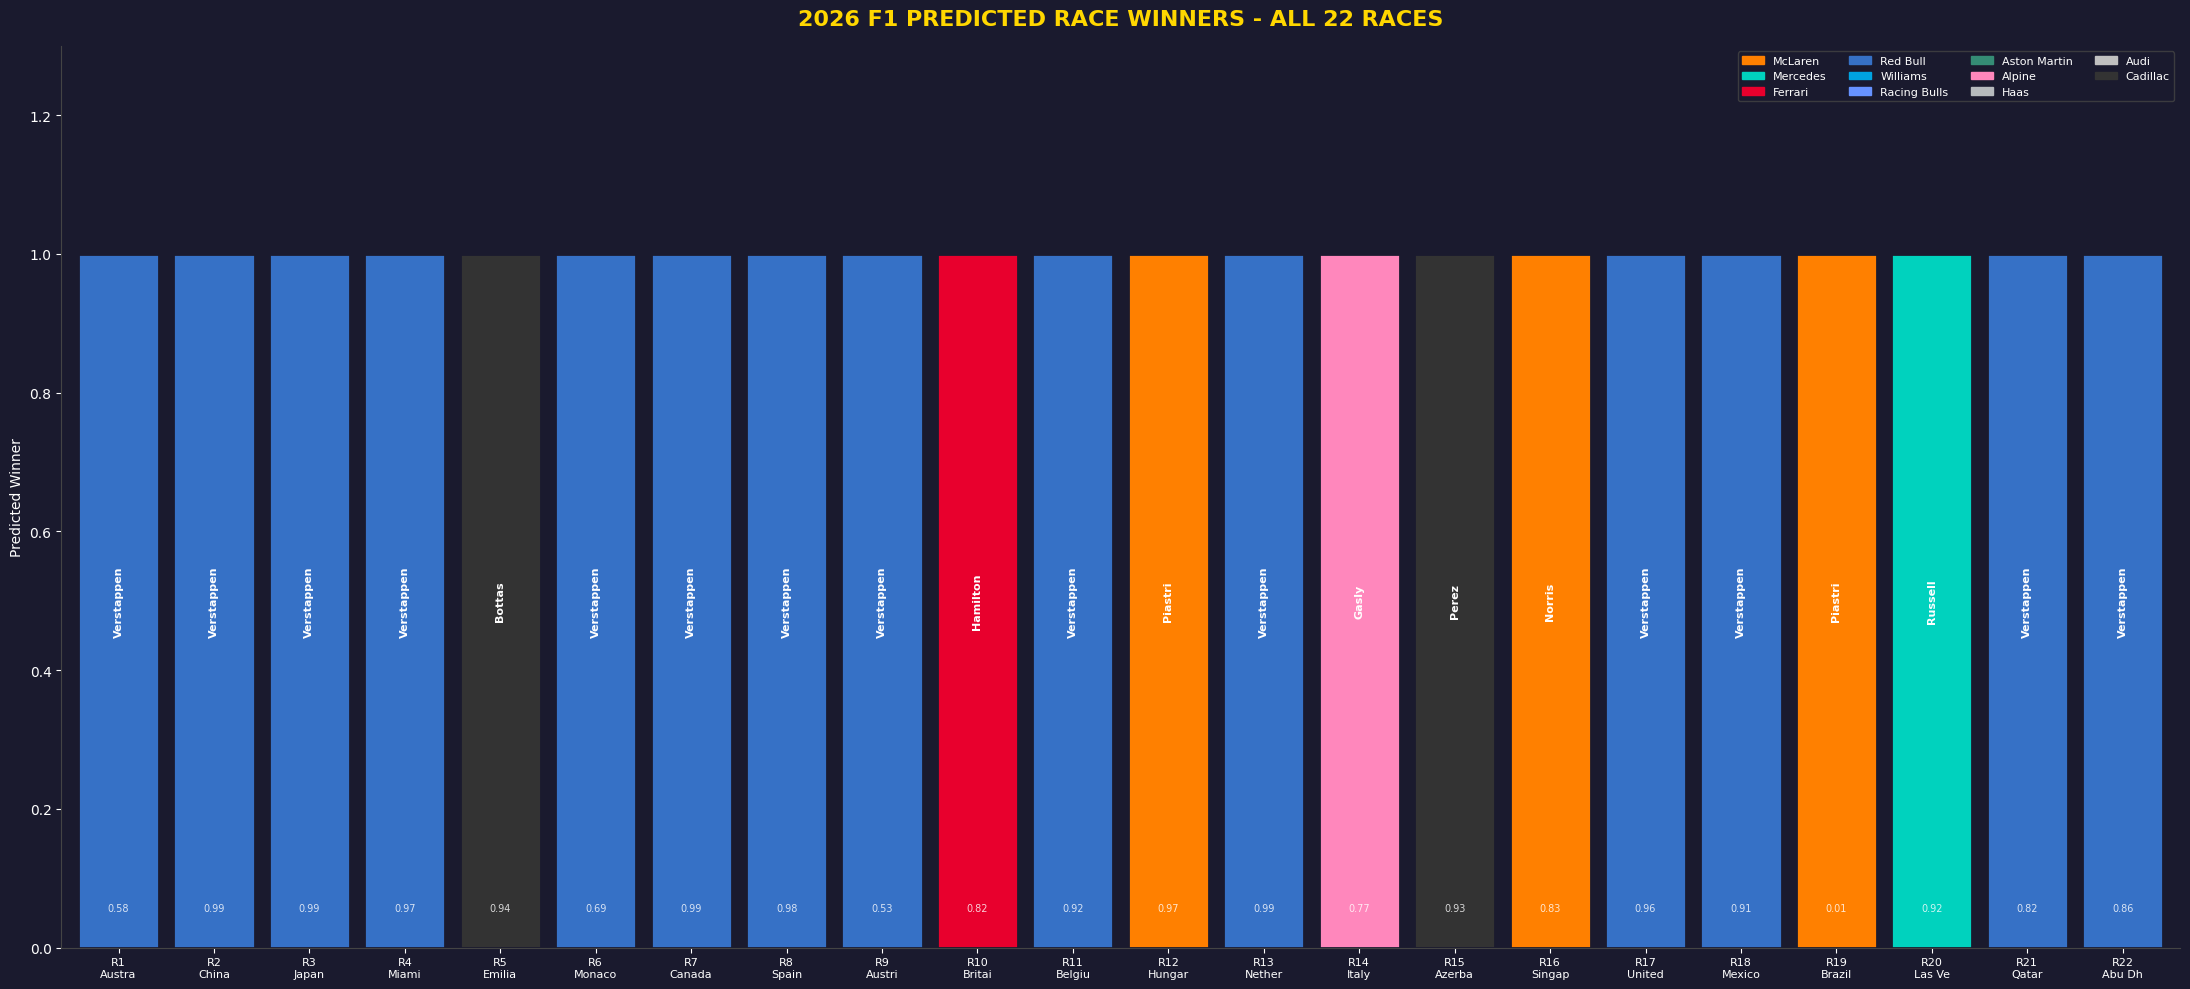

Saved: race_winners_2026.png


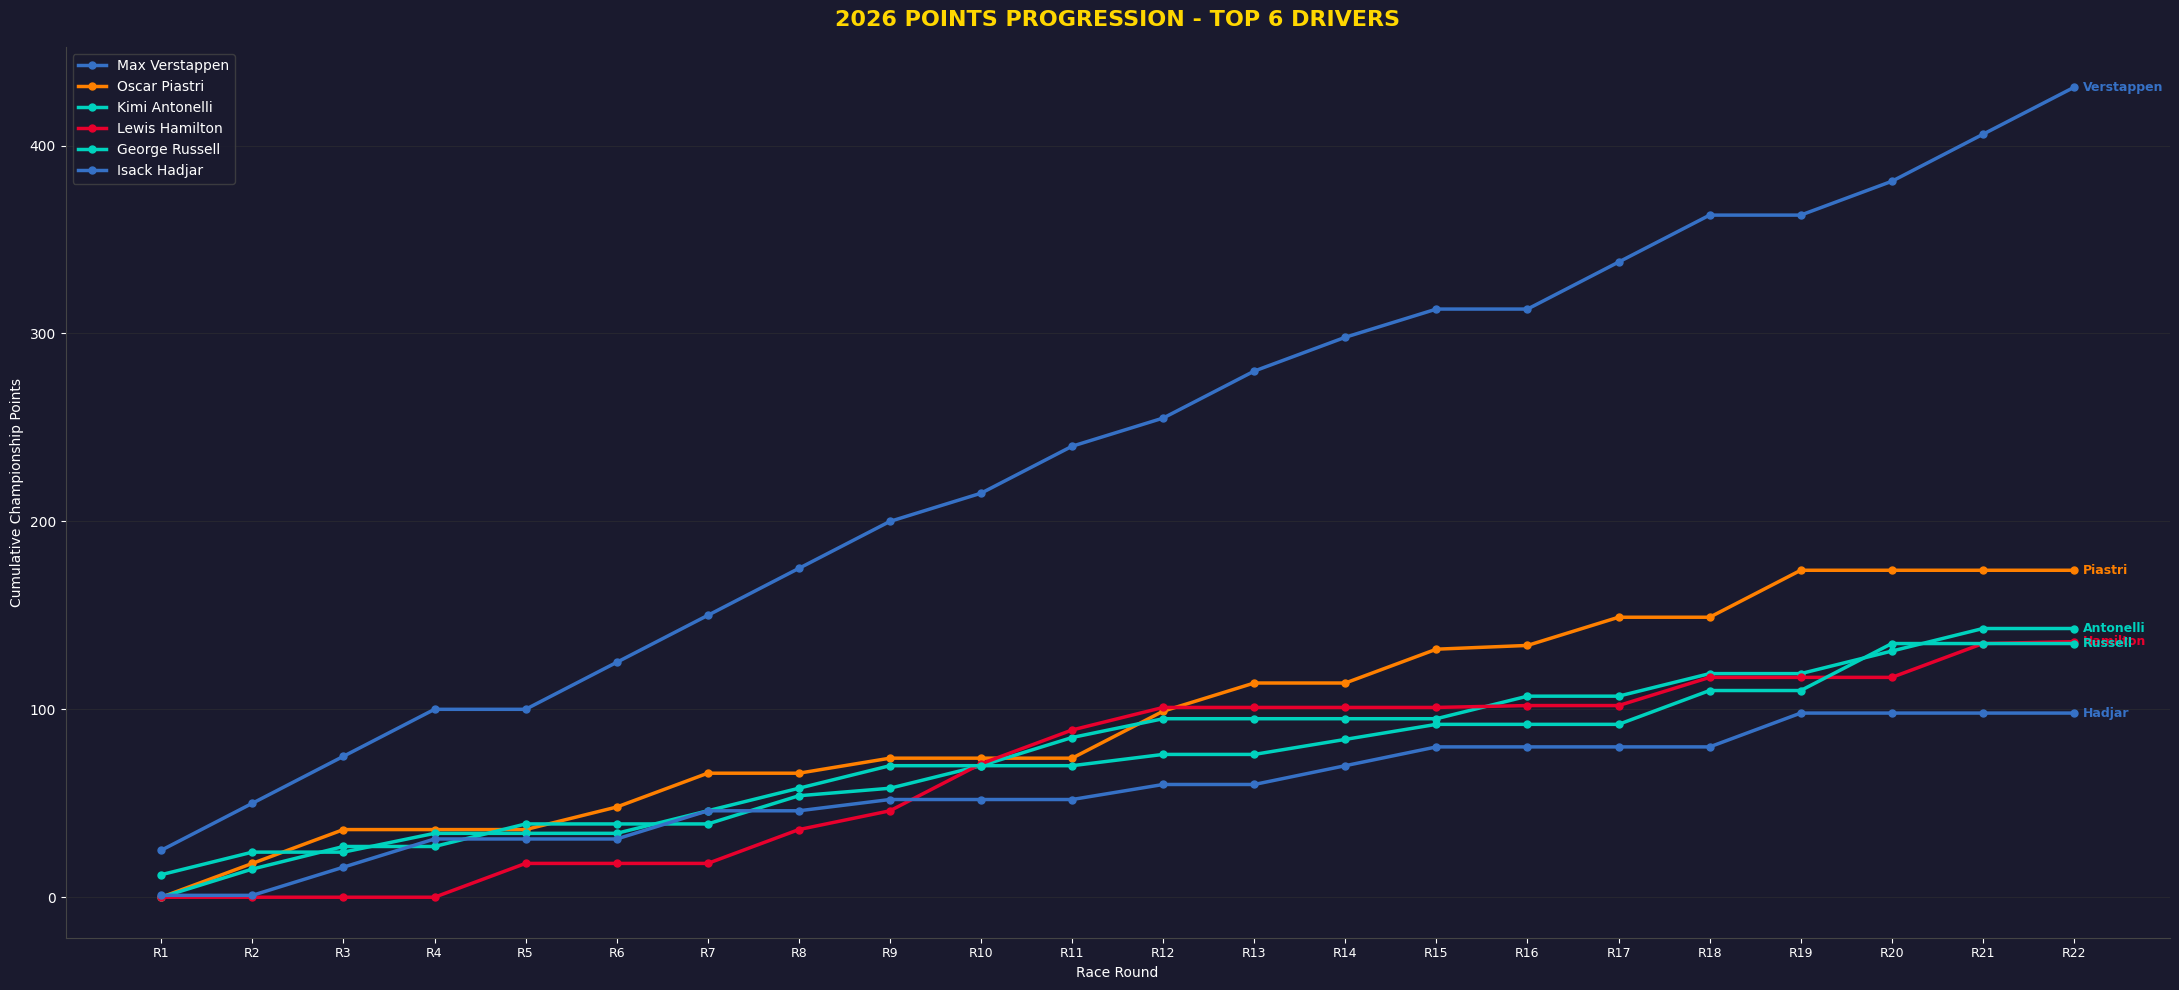

Saved: points_progression_2026.png

Cell 5 complete - All 3 visualizations saved!
Files saved:
  championship_standings_2026.png
  race_winners_2026.png
  points_progression_2026.png


In [5]:
# Cell 5: 2026 Championship Visualizations

print("Generating 2026 Championship Visualizations...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# TEAM COLORS
# ─────────────────────────────────────────────────────────────

team_colors = {
    'McLaren'      : '#FF8000',
    'Mercedes'     : '#00D2BE',
    'Ferrari'      : '#E8002D',
    'Red Bull'     : '#3671C6',
    'Williams'     : '#00A3E0',
    'Racing Bulls' : '#6692FF',
    'Aston Martin' : '#358C75',
    'Alpine'       : '#FF87BC',
    'Haas'         : '#B6BABD',
    'Audi'         : '#C0C0C0',
    'Cadillac'     : '#333333',
}

# ─────────────────────────────────────────────────────────────
# FIGURE 1: DRIVER CHAMPIONSHIP STANDINGS BAR CHART
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('2026 F1 CHAMPIONSHIP PREDICTION',
             fontsize=22, fontweight='bold',
             color='#FFD700', y=1.01)

# ── Panel 1: Driver Points ───────────────────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('#1a1a2e')

top15       = driver_standings_2026.head(15)
bar_colors  = [team_colors.get(t, '#ffffff')
               for t in top15['team']]

bars = ax1.barh(
    top15['driver'][::-1],
    top15['points'][::-1],
    color=bar_colors[::-1],
    edgecolor='none', height=0.7
)

# Add point labels
for bar, pts in zip(bars, top15['points'][::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(pts)}pts', va='center', color='white', fontsize=9)

# Champion crown marker
ax1.text(top15['points'].max() + 5,
         len(top15) - 1 - 0.05,
         ' CHAMPION', color='#FFD700',
         fontsize=8, fontweight='bold', va='center')

ax1.set_facecolor('#1a1a2e')
ax1.set_title('Driver Championship Standings',
              color='#FFD700', fontsize=13, fontweight='bold')
ax1.set_xlabel('Championship Points', color='white')
ax1.tick_params(colors='white', labelsize=9)
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, top15['points'].max() * 1.18)

# ── Panel 2: Constructor Championship ───────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('#1a1a2e')

const_colors = [team_colors.get(t, '#ffffff')
                for t in constructor_standings_2026['team']]

bars2 = ax2.bar(
    constructor_standings_2026['team'],
    constructor_standings_2026['points'],
    color=const_colors,
    edgecolor='none', width=0.6
)

for bar, pts in zip(bars2, constructor_standings_2026['points']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 8,
             f'{int(pts)}', ha='center',
             color='white', fontsize=9, fontweight='bold')

ax2.set_facecolor('#1a1a2e')
ax2.set_title('Constructor Championship Standings',
              color='#FFD700', fontsize=13, fontweight='bold')
ax2.set_ylabel('Championship Points', color='white')
ax2.tick_params(colors='white', labelsize=8)
ax2.set_xticklabels(constructor_standings_2026['team'],
                    rotation=45, ha='right')
ax2.spines['bottom'].set_color('#444')
ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, constructor_standings_2026['points'].max() * 1.15)

# ── Panel 3: Race Win Distribution ──────────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('#1a1a2e')

win_dist   = race_results_df['winner'].value_counts()
win_colors = [team_colors.get(
    drivers_df[drivers_df['driver'] == d]['team'].values[0], '#ffffff')
    for d in win_dist.index]

bars3 = ax3.barh(
    win_dist.index[::-1],
    win_dist.values[::-1],
    color=win_colors[::-1],
    edgecolor='none', height=0.7
)

for bar, wins in zip(bars3, win_dist.values[::-1]):
    ax3.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height()/2,
             f'{int(wins)} wins',
             va='center', color='white', fontsize=9)

ax3.set_facecolor('#1a1a2e')
ax3.set_title('Race Wins by Driver (22 Races)',
              color='#FFD700', fontsize=13, fontweight='bold')
ax3.set_xlabel('Number of Wins', color='white')
ax3.tick_params(colors='white', labelsize=9)
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_xlim(0, win_dist.max() * 1.25)

# ── Panel 4: Points Gap to Champion ─────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('#1a1a2e')

champion_pts = driver_standings_2026.iloc[0]['points']
top10        = driver_standings_2026.head(10).copy()
top10['gap'] = champion_pts - top10['points']

gap_colors = [team_colors.get(t, '#ffffff') for t in top10['team']]

bars4 = ax4.bar(
    range(len(top10)),
    top10['gap'],
    color=gap_colors,
    edgecolor='none', width=0.6
)

for bar, gap in zip(bars4, top10['gap']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'-{int(gap)}', ha='center',
             color='white', fontsize=9)

ax4.set_facecolor('#1a1a2e')
ax4.set_title('Points Gap to Champion (Top 10)',
              color='#FFD700', fontsize=13, fontweight='bold')
ax4.set_ylabel('Points Behind Champion', color='white')
ax4.set_xticks(range(len(top10)))
ax4.set_xticklabels(
    [d.split()[-1] for d in top10['driver']],
    rotation=45, ha='right', fontsize=9
)
ax4.tick_params(colors='white')
ax4.spines['bottom'].set_color('#444')
ax4.spines['left'].set_color('#444')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('championship_standings_2026.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Saved: championship_standings_2026.png")

# ─────────────────────────────────────────────────────────────
# FIGURE 2: RACE BY RACE WINNER CHART
# ─────────────────────────────────────────────────────────────

fig2, ax = plt.subplots(figsize=(22, 10))
fig2.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

# Plot each race winner as colored block
for _, row in race_results_df.iterrows():
    rnd    = int(row['round'])
    driver = row['winner']
    team   = row['winner_team']
    prob   = row['winner_prob']
    color  = team_colors.get(team, '#ffffff')

    ax.bar(rnd, 1, color=color, edgecolor='#1a1a2e',
           linewidth=2, width=0.85)
    ax.text(rnd, 0.5,
            driver.split()[-1],
            ha='center', va='center',
            color='white', fontsize=8,
            fontweight='bold', rotation=90)
    ax.text(rnd, 0.05,
            f'{prob:.2f}',
            ha='center', va='bottom',
            color='white', fontsize=7, alpha=0.8)

ax.set_xlim(0.4, 22.6)
ax.set_ylim(0, 1.3)
ax.set_xticks(range(1, 23))
ax.set_xticklabels(
    [f"R{r}\n{race_results_df.iloc[r-1]['race'][:6]}"
     for r in range(1, 23)],
    color='white', fontsize=8
)
ax.set_title('2026 F1 PREDICTED RACE WINNERS - ALL 22 RACES',
             color='#FFD700', fontsize=16,
             fontweight='bold', pad=15)
ax.set_ylabel('Predicted Winner', color='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_teams = list(team_colors.keys())
legend_patches = [
    mpatches.Patch(color=team_colors[t], label=t)
    for t in legend_teams
]
ax.legend(handles=legend_patches,
          loc='upper right',
          ncol=4,
          fontsize=8,
          facecolor='#1a1a2e',
          edgecolor='#444',
          labelcolor='white')

plt.tight_layout()
plt.savefig('race_winners_2026.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Saved: race_winners_2026.png")

# ─────────────────────────────────────────────────────────────
# FIGURE 3: POINTS PROGRESSION ACROSS SEASON
# ─────────────────────────────────────────────────────────────

fig3, ax3 = plt.subplots(figsize=(22, 10))
fig3.patch.set_facecolor('#1a1a2e')
ax3.set_facecolor('#1a1a2e')

# Build cumulative points per driver per race
top6_drivers = driver_standings_2026.head(6)['driver'].tolist()

for driver in top6_drivers:
    team    = drivers_df[drivers_df['driver'] == driver]['team'].values[0]
    color   = team_colors.get(team, '#ffffff')
    cum_pts = []
    total   = 0

    for race_name in calendar_df['race']:
        race_data = detailed_df[
            (detailed_df['race'] == race_name) &
            (detailed_df['driver'] == driver)
        ]
        pts    = race_data['points'].values[0] if len(race_data) > 0 else 0
        total += pts
        cum_pts.append(total)

    ax3.plot(range(1, 23), cum_pts,
             color=color, linewidth=2.5,
             marker='o', markersize=5,
             label=driver)
    ax3.text(22.1, cum_pts[-1],
             driver.split()[-1],
             color=color, fontsize=9,
             fontweight='bold', va='center')

ax3.set_facecolor('#1a1a2e')
ax3.set_title('2026 POINTS PROGRESSION - TOP 6 DRIVERS',
              color='#FFD700', fontsize=16,
              fontweight='bold', pad=15)
ax3.set_xlabel('Race Round', color='white')
ax3.set_ylabel('Cumulative Championship Points', color='white')
ax3.set_xticks(range(1, 23))
ax3.set_xticklabels(
    [f"R{r}" for r in range(1, 23)],
    color='white', fontsize=9
)
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='y', color='#333', linewidth=0.5, alpha=0.7)
ax3.legend(facecolor='#1a1a2e',
           edgecolor='#444',
           labelcolor='white',
           fontsize=10,
           loc='upper left')

plt.tight_layout()
plt.savefig('points_progression_2026.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("Saved: points_progression_2026.png")

print("\n" + "="*60)
print("Cell 5 complete - All 3 visualizations saved!")
print("Files saved:")
print("  championship_standings_2026.png")
print("  race_winners_2026.png")
print("  points_progression_2026.png")
print("="*60)

Generating Summary Card...


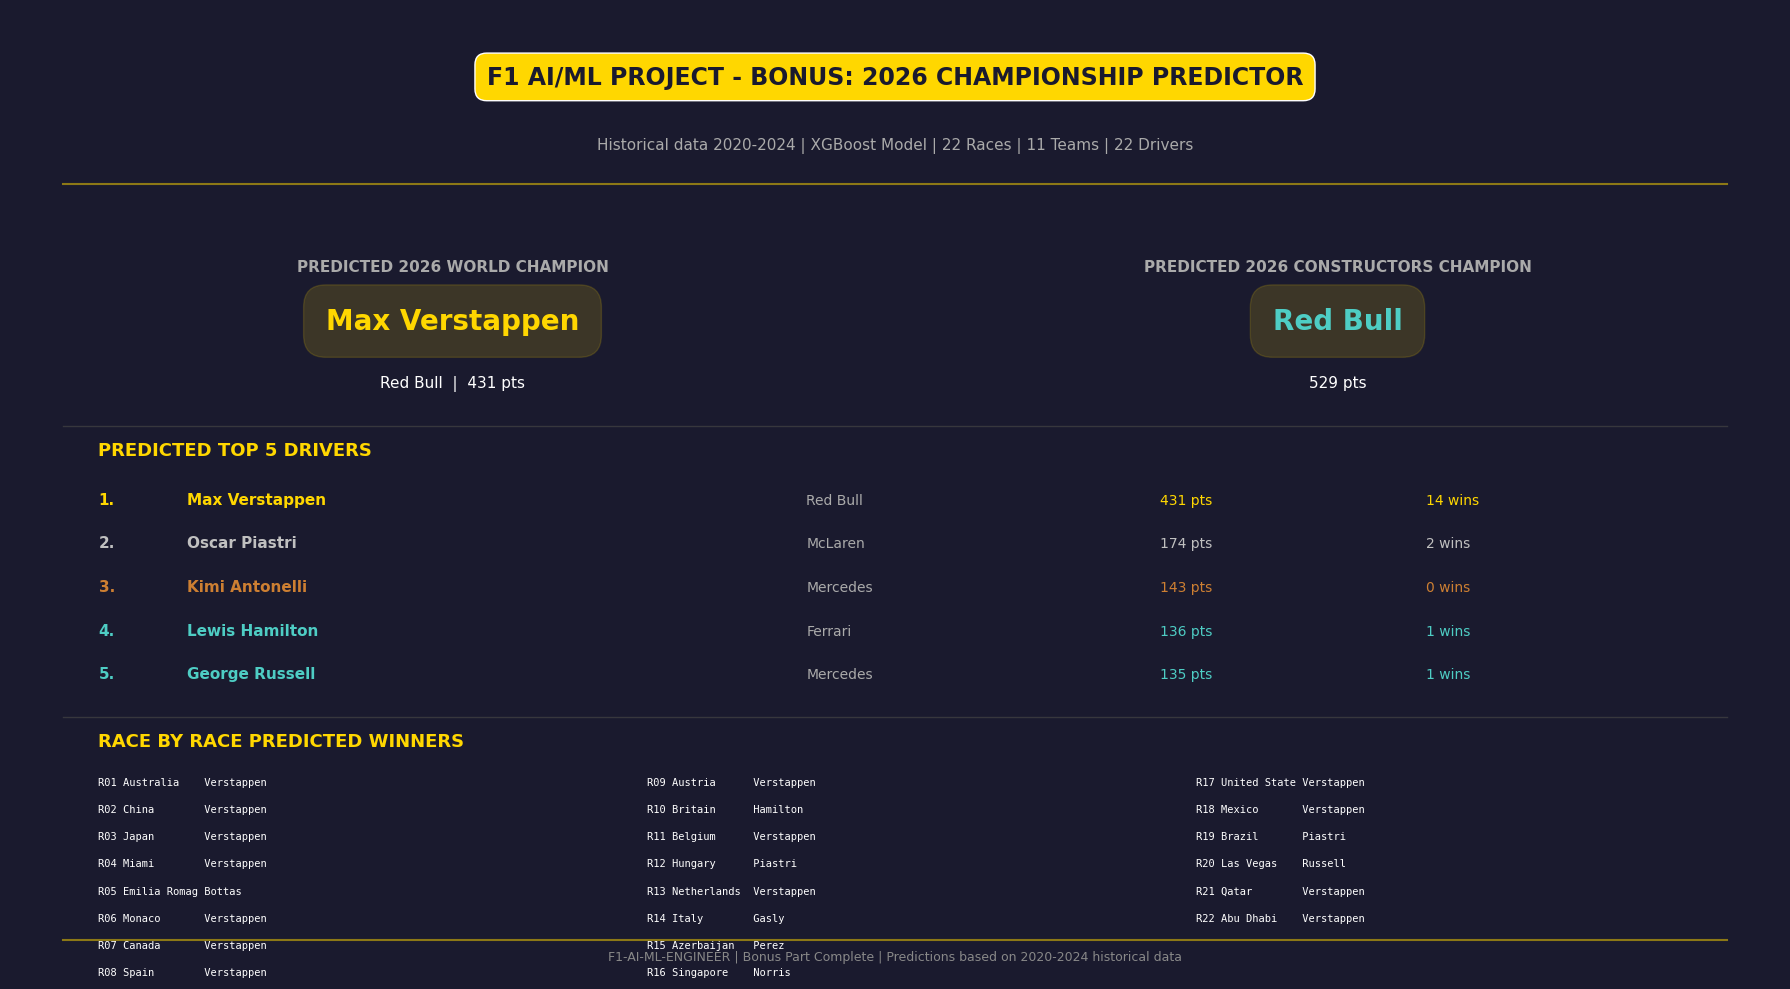

Saved: part6_summary_card.png
Saved: race_predictions_2026.csv
Saved: championship_standings_2026.csv
Saved: prediction_2026_summary.txt

BONUS PART COMPLETE - 2026 CHAMPIONSHIP PREDICTOR!

Predicted 2026 World Champion  : Max Verstappen
Predicted 2026 Team Champion   : Red Bull
Races predicted                : 22
Model used                     : XGBoost

Files saved in 06_2026_prediction/:
  race_predictions_2026.csv                  [SAVED]
  championship_standings_2026.csv            [SAVED]
  championship_standings_2026.png            [SAVED]
  race_winners_2026.png                      [SAVED]
  points_progression_2026.png                [SAVED]
  part6_summary_card.png                     [SAVED]
  prediction_2026_summary.txt                [SAVED]

F1 AI/ML Project - ALL PARTS COMPLETE!


In [8]:
# Cell 6: Summary Card + Save All Results

from datetime import datetime
import os

print("Generating Summary Card...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# FIX VARIABLE NAMES FROM CELL 5
# ─────────────────────────────────────────────────────────────

championship_df = driver_standings_2026.rename(columns={
    'points': 'predicted_points',
    'wins'  : 'predicted_wins'
}).copy()

constructor_pts = constructor_standings_2026.set_index('team')['points']

# ─────────────────────────────────────────────────────────────
# 1. SUMMARY CARD
# ─────────────────────────────────────────────────────────────

predicted_champion      = championship_df.iloc[0]['driver']
predicted_champion_pts  = int(championship_df.iloc[0]['predicted_points'])
predicted_champion_team = championship_df.iloc[0]['team']
predicted_constructor   = constructor_pts.idxmax()
predicted_constructor_pts = int(constructor_pts.max())

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
title_box = dict(boxstyle='round,pad=0.5',
                 facecolor='#FFD700', alpha=1.0)
ax.text(5, 9.3,
        'F1 AI/ML PROJECT - BONUS: 2026 CHAMPIONSHIP PREDICTOR',
        ha='center', va='center', fontsize=17,
        fontweight='bold', color='#1a1a2e', bbox=title_box)

ax.text(5, 8.6,
        'Historical data 2020-2024 | XGBoost Model | 22 Races | 11 Teams | 22 Drivers',
        ha='center', va='center', fontsize=11, color='#aaaaaa')

ax.plot([0.3, 9.7], [8.2, 8.2],
        color='#FFD700', linewidth=1.5, alpha=0.5)

# ── Predicted Champion Box ───────────────────────────────────
champ_box = dict(boxstyle='round,pad=0.8',
                 facecolor='#FFD700', alpha=0.15,
                 edgecolor='#FFD700')

ax.text(2.5, 7.3,
        'PREDICTED 2026 WORLD CHAMPION',
        ha='center', fontsize=11,
        color='#aaaaaa', fontweight='bold')
ax.text(2.5, 6.7,
        predicted_champion,
        ha='center', fontsize=20,
        color='#FFD700', fontweight='bold', bbox=champ_box)
ax.text(2.5, 6.1,
        f'{predicted_champion_team}  |  {predicted_champion_pts} pts',
        ha='center', fontsize=11, color='white')

# ── Predicted Constructor Box ────────────────────────────────
ax.text(7.5, 7.3,
        'PREDICTED 2026 CONSTRUCTORS CHAMPION',
        ha='center', fontsize=11,
        color='#aaaaaa', fontweight='bold')
ax.text(7.5, 6.7,
        predicted_constructor,
        ha='center', fontsize=20,
        color='#4ecdc4', fontweight='bold', bbox=champ_box)
ax.text(7.5, 6.1,
        f'{predicted_constructor_pts} pts',
        ha='center', fontsize=11, color='white')

ax.plot([0.3, 9.7], [5.7, 5.7],
        color='#444', linewidth=1, alpha=0.7)

# ── Top 5 Drivers ────────────────────────────────────────────
ax.text(0.5, 5.4, 'PREDICTED TOP 5 DRIVERS',
        fontsize=13, fontweight='bold', color='#FFD700')

medal_colors = ['#FFD700', '#C0C0C0',
                '#CD7F32', '#4ecdc4', '#4ecdc4']

for i, (_, row) in enumerate(championship_df.head(5).iterrows()):
    y = 4.9 - i * 0.45
    ax.text(0.5, y, f"{i+1}.",
            fontsize=11, color=medal_colors[i], fontweight='bold')
    ax.text(1.0, y, row['driver'],
            fontsize=11, color=medal_colors[i], fontweight='bold')
    ax.text(4.5, y, row['team'],
            fontsize=10, color='#aaaaaa')
    ax.text(6.5, y, f"{int(row['predicted_points'])} pts",
            fontsize=10, color=medal_colors[i])
    wins_val = int(row['predicted_wins']) \
               if 'predicted_wins' in row else '-'
    ax.text(8.0, y, f"{wins_val} wins",
            fontsize=10, color=medal_colors[i])

ax.plot([0.3, 9.7], [2.7, 2.7],
        color='#444', linewidth=1, alpha=0.7)

# ── Race by Race Summary ─────────────────────────────────────
ax.text(0.5, 2.4, 'RACE BY RACE PREDICTED WINNERS',
        fontsize=13, fontweight='bold', color='#FFD700')

col   = 0
row_y = 2.0
for i, (_, race) in enumerate(race_results_df.iterrows()):
    x = 0.5 + col * 3.1
    ax.text(x, row_y,
            f"R{int(race['round']):02d} "
            f"{race['race'][:12]:<12} "
            f"{race['winner'].split()[-1]}",
            fontsize=7.5, color='white',
            fontfamily='monospace')
    row_y -= 0.28
    if (i + 1) % 8 == 0:
        col  += 1
        row_y = 2.0

# Footer
ax.plot([0.3, 9.7], [0.4, 0.4],
        color='#FFD700', linewidth=1.5, alpha=0.5)
ax.text(5, 0.2,
        'F1-AI-ML-ENGINEER | Bonus Part Complete | Predictions based on 2020-2024 historical data',
        ha='center', fontsize=9, color='#888888')

plt.tight_layout()
plt.savefig('part6_summary_card.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: part6_summary_card.png")

# ─────────────────────────────────────────────────────────────
# 2. SAVE CSVs
# ─────────────────────────────────────────────────────────────

race_results_df.to_csv('race_predictions_2026.csv', index=False)
print("Saved: race_predictions_2026.csv")

driver_standings_2026.to_csv('championship_standings_2026.csv', index=False)
print("Saved: championship_standings_2026.csv")

# ─────────────────────────────────────────────────────────────
# 3. SAVE SUMMARY TEXT
# ─────────────────────────────────────────────────────────────

summary = f"""F1 AI/ML PROJECT - BONUS: 2026 CHAMPIONSHIP PREDICTOR
=======================================================
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Model used: {best_model_name}
Races predicted: {len(race_results_df)}
Drivers: 22 | Teams: 11

PREDICTED 2026 WORLD CHAMPION:
{predicted_champion} ({predicted_champion_team}) - {predicted_champion_pts} pts

PREDICTED 2026 CONSTRUCTORS CHAMPION:
{predicted_constructor} - {predicted_constructor_pts} pts

PREDICTED TOP 10 DRIVERS:
{driver_standings_2026.head(10).to_string(index=False)}

RACE BY RACE PREDICTIONS:
{race_results_df[['round','race','winner']].to_string(index=False)}

FILES SAVED:
- race_predictions_2026.csv
- championship_standings_2026.csv
- championship_standings_2026.png
- race_winners_2026.png
- points_progression_2026.png
- part6_summary_card.png
- prediction_2026_summary.txt
"""

with open('prediction_2026_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("Saved: prediction_2026_summary.txt")

# ─────────────────────────────────────────────────────────────
# 4. FINAL PRINT
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("BONUS PART COMPLETE - 2026 CHAMPIONSHIP PREDICTOR!")
print("="*60)
print(f"\nPredicted 2026 World Champion  : {predicted_champion}")
print(f"Predicted 2026 Team Champion   : {predicted_constructor}")
print(f"Races predicted                : {len(race_results_df)}")
print(f"Model used                     : {best_model_name}")
print(f"\nFiles saved in 06_2026_prediction/:")
for fname in ['race_predictions_2026.csv',
              'championship_standings_2026.csv',
              'championship_standings_2026.png',
              'race_winners_2026.png',
              'points_progression_2026.png',
              'part6_summary_card.png',
              'prediction_2026_summary.txt']:
    exists = 'SAVED' if os.path.exists(fname) else 'MISSING'
    print(f"  {fname:<42} [{exists}]")

print("\nF1 AI/ML Project - ALL PARTS COMPLETE!")